# Problem Statement

To estimate the delivery time for food for it customers on the basis of what they are ordering, from where they are ordering and also who are the delivery partners.

**Feature Details**

**market_id** : integer id for the market where the restaurant lies

**created_at** : the timestamp at which the order was placed

**actual_delivery_time** : the timestamp when the order was delivered

**store_primary_category** : category for the restaurant

**order_protocol** : integer code value for order protocol(how the order was placed
ie: through porter, call to restaurant, pre booked, third part etc)

**total_items subtotal** : final price of the order

**num_distinct_items** : the number of distinct items in the order

**min_item_price** : price of the cheapest item in the order

**max_item_price** : price of the costliest item in order

**total_onshift_partners** : number of delivery partners on duty at the time order was placed

**total_busy_partners** : number of delivery partners attending to other tasks

**total_outstanding_orders** : total number of orders to be fulfilled at the moment

**estimated_store_to_consumer_driving_duration** : approximate travel time from restaurant to customer

# Loading Of Libraries

In [1]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.4 MB/s eta 0:00:00


In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# importing keras Libraries

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import BatchNormalization,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Flatten,
    Dense,
    Concatenate,
    BatchNormalization,
    Dropout
)

from tensorflow.keras.models import Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


from keras_tuner import RandomSearch

In [3]:
df= pd.read_csv("data_2.csv")

In [4]:
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   created_at                                    175777 non-null  object 
 2   actual_delivery_time                          175777 non-null  object 
 3   store_primary_category                        175777 non-null  int64  
 4   order_protocol                                175777 non-null  float64
 5   total_items                                   175777 non-null  int64  
 6   subtotal                                      175777 non-null  int64  
 7   num_distinct_items                            175777 non-null  int64  
 8   min_item_price                                175777 non-null  int64  
 9   max_item_price                                17

In [6]:
df.isnull().sum()*100/len(df)

,0
market_id,0.0
created_at,0.0
actual_delivery_time,0.0
store_primary_category,0.0
order_protocol,0.0
total_items,0.0
subtotal,0.0
num_distinct_items,0.0
min_item_price,0.0
max_item_price,0.0


We do not have any NULL or missing values in the dataset

In [7]:
df.describe()

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
count,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000
mean,2.743726,35.887949,2.911752,3.204976,2697.111147,2.675060,684.965433,1160.158616,44.918664,41.861381,58.230115,546.077240
std,1.330963,20.728254,1.513128,2.674055,1828.554893,1.625681,519.882924,560.828571,34.544724,32.168505,52.731043,218.717798
min,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000,0.000000
25%,2.000000,18.000000,1.000000,2.000000,1412.000000,1.000000,299.000000,799.000000,17.000000,15.000000,17.000000,384.000000
50%,2.000000,38.000000,3.000000,3.000000,2224.000000,2.000000,595.000000,1095.000000,37.000000,35.000000,41.000000,544.000000
75%,4.000000,55.000000,4.000000,4.000000,3410.000000,3.000000,942.000000,1395.000000,66.000000,63.000000,85.000000,703.000000
max,6.000000,72.000000,7.000000,411.000000,26800.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000,2088.000000


In [8]:
df.nunique()

,0
market_id,6
created_at,162649
actual_delivery_time,160344
store_primary_category,73
order_protocol,7
total_items,54
subtotal,8182
num_distinct_items,20
min_item_price,2251
max_item_price,2585


# Data Pre Processing

In [89]:
df_new= df.copy()

In [90]:
df_new.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0


In [91]:
df_new["created_at"] = pd.to_datetime(df_new["created_at"])
df_new["actual_delivery_time"] = pd.to_datetime(df_new["actual_delivery_time"])

## Feature engineering

In [92]:
df_new["Time_taken_delivery"]= df_new["actual_delivery_time"] - df_new["created_at"]

### Time based Features

In [93]:
df_new["order_hour"] = df_new["created_at"].dt.hour
df_new["order_day_of_week"] = df_new["created_at"].dt.weekday
df_new["is_weekend"] = df_new["order_day_of_week"].isin([5,6]).astype(int)
df_new["delivery_in_minutes"] = df_new["Time_taken_delivery"].dt.total_seconds() / 60


Here , **delivery_in_minutes** is our **target Variable**

### Feature to estimate demand

In [94]:


df_new["orders_per_dasher"] = np.round(
    np.where(
        df_new["total_onshift_dashers"] > 0,
        df_new["total_outstanding_orders"] / df_new["total_onshift_dashers"],
        0
    ),
2)

df_new["busy_dasher_ratio"] = np.round(
    np.where(
        df_new["total_onshift_dashers"] > 0,
        df_new["total_busy_dashers"] / df_new["total_onshift_dashers"],
        0
    ),
2)



### Price-related Features

In [95]:
df_new["price_range"] = df_new["max_item_price"] - df_new["min_item_price"]
df_new["avg_item_price"] = df_new["subtotal"] / df_new["total_items"]


In [35]:
df_new.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,...,estimated_store_to_consumer_driving_duration,Time_taken_delivery,order_hour,order_day_of_week,is_weekend,delivery_in_minutes,orders_per_dasher,busy_dasher_ratio,price_range,avg_item_price
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,...,861.0,0 days 00:47:00,22,4,0,47.0,0.64,0.42,682,860.25
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,...,690.0,0 days 00:44:00,21,1,0,44.0,2.00,2.00,0,1900.00
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,...,289.0,0 days 00:55:00,0,0,0,55.0,2.25,0.75,784,1192.75
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,...,795.0,0 days 00:59:00,3,3,0,59.0,1.60,1.20,0,1525.00
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,...,205.0,0 days 00:46:00,2,1,0,46.0,1.40,1.00,770,1810.00


In [96]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 23 columns):
 #   Column                                        Non-Null Count   Dtype          
---  ------                                        --------------   -----          
 0   market_id                                     175777 non-null  float64        
 1   created_at                                    175777 non-null  datetime64[ns] 
 2   actual_delivery_time                          175777 non-null  datetime64[ns] 
 3   store_primary_category                        175777 non-null  int64          
 4   order_protocol                                175777 non-null  float64        
 5   total_items                                   175777 non-null  int64          
 6   subtotal                                      175777 non-null  int64          
 7   num_distinct_items                            175777 non-null  int64          
 8   min_item_price                              

## Outlier detection

In [97]:
df_new.skew(numeric_only=True)

,0
market_id,0.225556
store_primary_category,-0.096707
order_protocol,0.109423
total_items,23.286019
subtotal,1.918445
num_distinct_items,1.574312
min_item_price,2.338844
max_item_price,2.204340
total_onshift_dashers,0.856865
total_busy_dashers,0.778571


|skewness| > 1 → strong skew

<Axes: xlabel='delivery_in_minutes'>

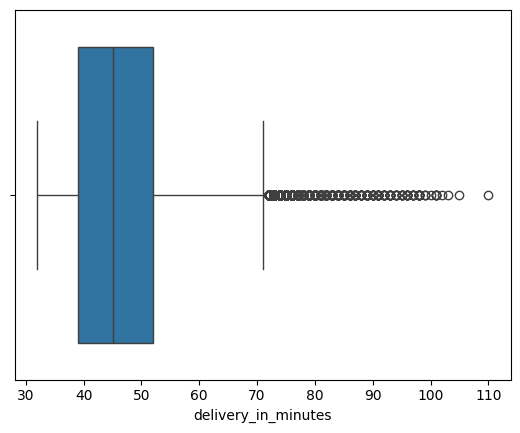

In [72]:
sns.boxplot(x=df_new["delivery_in_minutes"])

**Clipping extreme values (outliers)**

In [98]:
df_new["delivery_in_minutes"] = df_new["delivery_in_minutes"].clip(
    lower=df_new["delivery_in_minutes"].quantile(0.01),
    upper=df_new["delivery_in_minutes"].quantile(0.99)
)
df_new["orders_per_dasher"] = df_new["orders_per_dasher"].clip(
    lower=df_new["orders_per_dasher"].quantile(0.01),
    upper=df_new["orders_per_dasher"].quantile(0.99)
)
df_new["busy_dasher_ratio"] = df_new["busy_dasher_ratio"].clip(
    lower=df_new["busy_dasher_ratio"].quantile(0.01),
    upper=df_new["busy_dasher_ratio"].quantile(0.99)
)


In [99]:
df_new.skew(numeric_only=True)

,0
market_id,0.225556
store_primary_category,-0.096707
order_protocol,0.109423
total_items,23.286019
subtotal,1.918445
num_distinct_items,1.574312
min_item_price,2.338844
max_item_price,2.204340
total_onshift_dashers,0.856865
total_busy_dashers,0.778571


# EDA Univariate and Bivariate Analysis

<Axes: xlabel='order_day_of_week'>

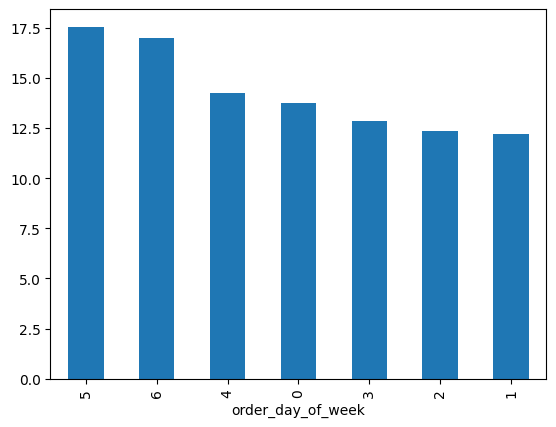

In [100]:
day_percent = df_new["order_day_of_week"].value_counts(normalize=True) * 100
day_percent = day_percent.sort_values(ascending=False)

day_percent.plot(kind="bar")

We can see that most number of orders are being delivered on the weekends

<Axes: xlabel='market_id'>

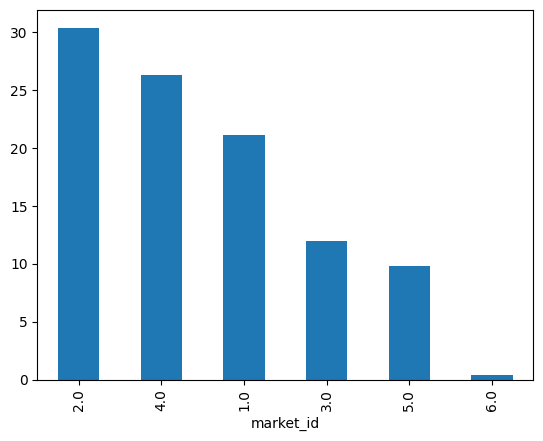

In [101]:
market_orders = df_new["market_id"].value_counts(normalize=True) * 100
market_orders = market_orders.sort_values(ascending=False)

market_orders.plot(kind="bar")

Most of the orders are from market 2 ID

In [102]:
df_new["order_protocol"].unique()

array([1., 2., 3., 5., 4., 6., 7.])

<Axes: xlabel='order_protocol'>

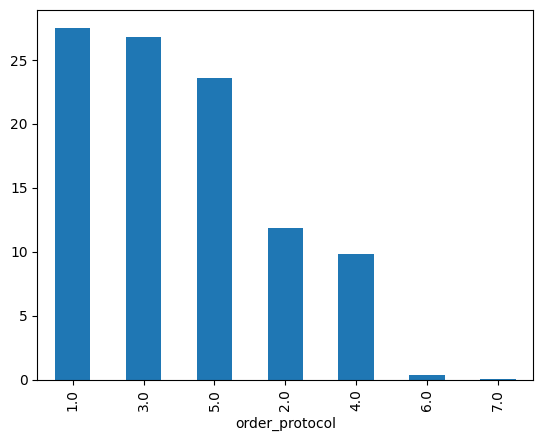

In [103]:
order_protocol = df_new["order_protocol"].value_counts(normalize=True) * 100
order_protocol = order_protocol.sort_values(ascending=False)

order_protocol.plot(kind="bar")

1,3,5 protocols were the most used source for ordering food

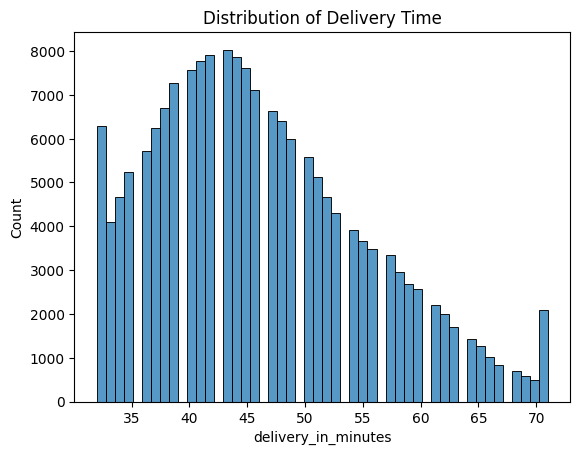

In [104]:
sns.histplot(df_new["delivery_in_minutes"], bins=50)
plt.title("Distribution of Delivery Time")
plt.show()

Most of the deliveries lies between 40 to 50 mins. we can observe that there are extreme delays as well for delivery time > 1 hour

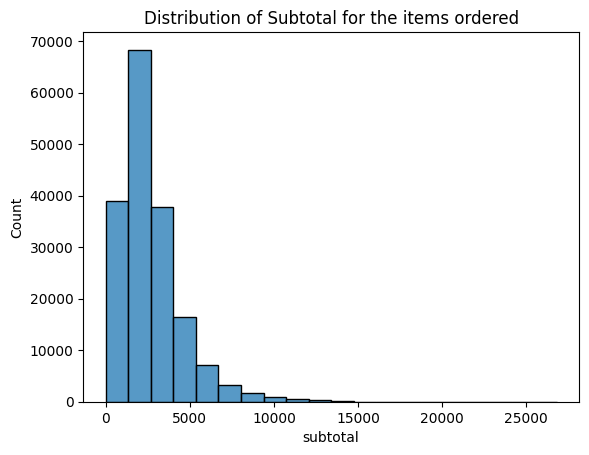

In [105]:
sns.histplot(df_new["subtotal"], bins=20)
plt.title("Distribution of Subtotal for the items ordered")
plt.show()

we can see a right skewed distribution graph with mots of the orders have total order value  < 5000 units

<Axes: xlabel='order_hour', ylabel='count'>

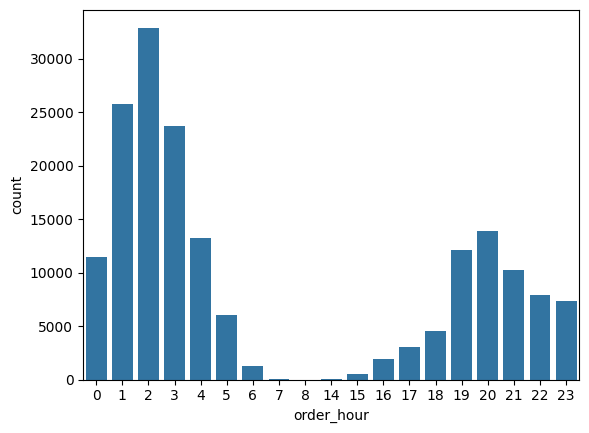

In [106]:
sns.countplot(x="order_hour", data=df_new)

Most of the food orders are being placed from 12 am in the night till 3 am in the morning. also we can see a spike in orders during the evning time as well from 4 pm till 11 pm.

<Axes: >

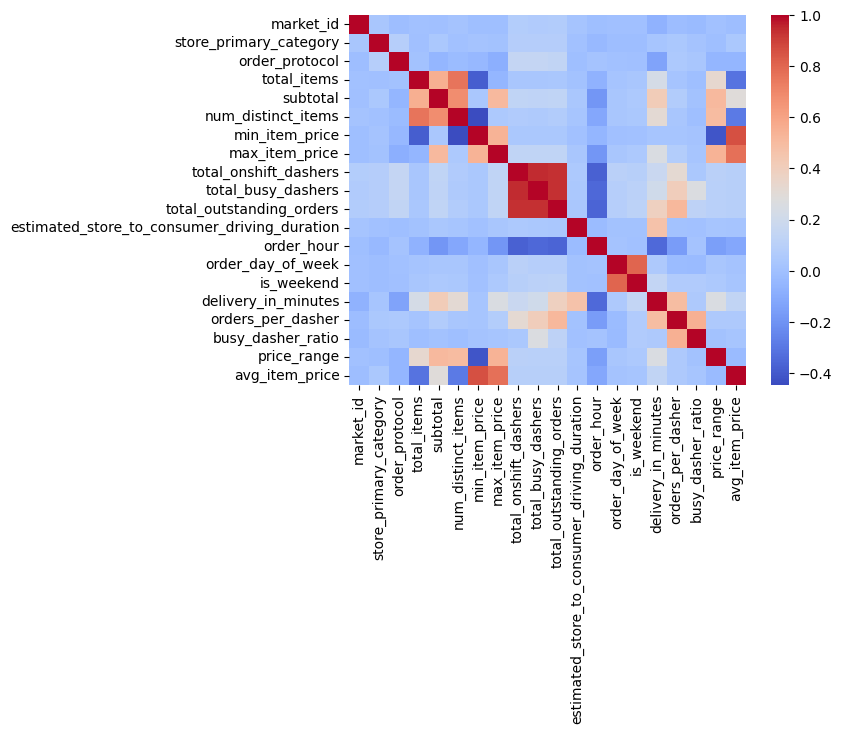

In [107]:
corr = df_new.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")

We can see from the correlation plot shown above

1.   the features correlated with target variable delivery in minutes are subtotal,estimated_store_to_consumer_driving_duration, total_outstanding_orders etc
2.   we can see that orders per dasher and total items are highly correlated to busy dasher ratio..which is quite evident from the fact that as number of orders per dasher increases ,  the dasher becomes busy more likely



**Delivery Time vs Number of Items**

<Axes: xlabel='delivery_in_minutes', ylabel='subtotal'>

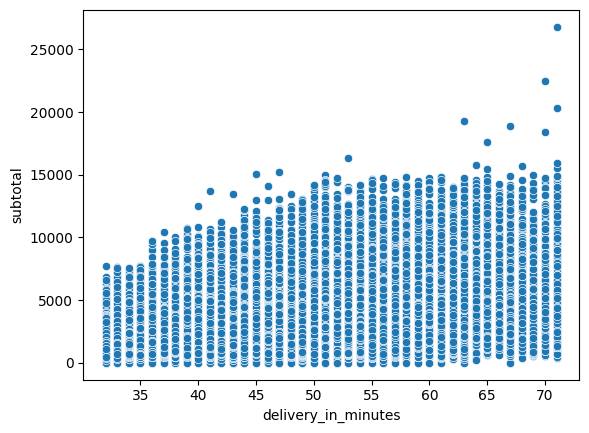

In [108]:
sns.scatterplot(x="delivery_in_minutes", y = "subtotal", data= df_new)

<Axes: xlabel='delivery_in_minutes', ylabel='estimated_store_to_consumer_driving_duration'>

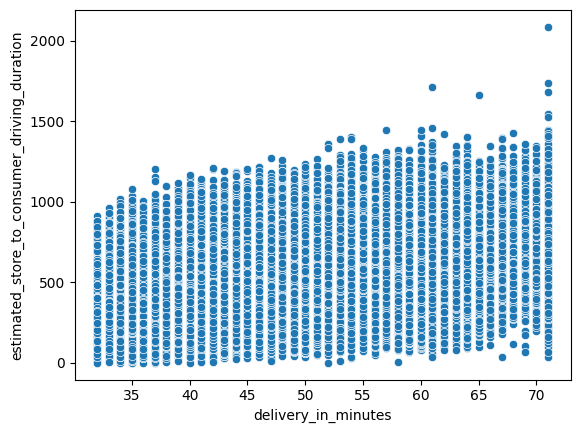

In [109]:
sns.scatterplot(x="delivery_in_minutes", y = "estimated_store_to_consumer_driving_duration", data= df_new)

More distance → longer delivery time

<Axes: xlabel='delivery_in_minutes', ylabel='orders_per_dasher'>

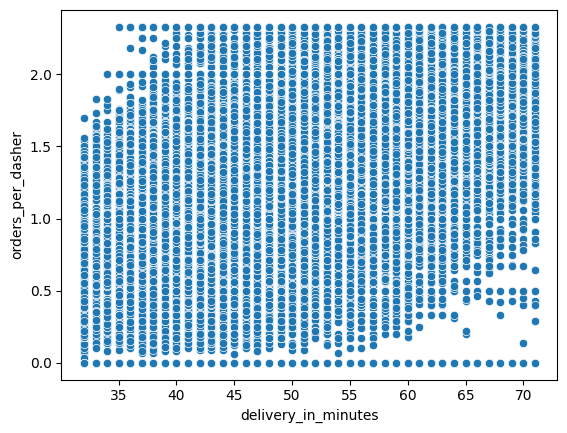

In [110]:
sns.scatterplot(x="delivery_in_minutes", y = "orders_per_dasher", data= df_new)

We can see a slight positive correlation between delivery in minutes and order per dasher.

<Axes: xlabel='order_hour', ylabel='delivery_in_minutes'>

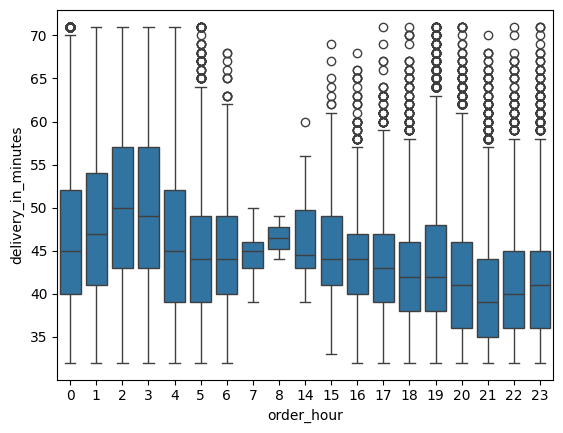

In [111]:
sns.boxplot(
    x="order_hour",
    y="delivery_in_minutes",
    data=df_new
)

Delivery delays are strongly influenced by time of day. during Evening (18–21 hrs) and Late Night / Early Morning (0–3 hrs, delivery times are the highest.

In [114]:
df_new.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,...,estimated_store_to_consumer_driving_duration,Time_taken_delivery,order_hour,order_day_of_week,is_weekend,delivery_in_minutes,orders_per_dasher,busy_dasher_ratio,price_range,avg_item_price
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,...,861.0,0 days 00:47:00,22,4,0,47.0,0.64,0.42,682,860.25
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,...,690.0,0 days 00:44:00,21,1,0,44.0,2.00,2.00,0,1900.00
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,...,289.0,0 days 00:55:00,0,0,0,55.0,2.25,0.75,784,1192.75
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,...,795.0,0 days 00:59:00,3,3,0,59.0,1.60,1.20,0,1525.00
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,...,205.0,0 days 00:46:00,2,1,0,46.0,1.40,1.00,770,1810.00


# Data preparation for Random Forest

In [153]:
df_new2= df_new.copy()

In [154]:
df_new2= df_new2.drop(["created_at", "actual_delivery_time", "Time_taken_delivery","min_item_price","max_item_price","total_busy_dashers","total_onshift_dashers","subtotal","total_outstanding_orders"], axis=1)

In [155]:
rf_features = [
    "market_id",
    "store_primary_category",
    "order_protocol",
    "total_items",
    "num_distinct_items",
    "avg_item_price",
    "price_range",
    "orders_per_dasher",
    "busy_dasher_ratio",
    "estimated_store_to_consumer_driving_duration",
    "order_hour",
    "order_day_of_week",
    "is_weekend"
]

## One-Hot Encode Categorical Variables

In [156]:
cat_cols = ["market_id", "store_primary_category", "order_protocol"]
target = "delivery_in_minutes"

In [157]:
X_rf = pd.get_dummies(
    df_new2[rf_features],
    columns=cat_cols,
    drop_first=True
)

y_rf = df_new2[target]

In [158]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.2,
    random_state=42
)

# Train Random Forest Model

In [160]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_rf, y_train_rf)

RandomForestRegressor(min_samples_leaf=2, min_samples_split=5, n_estimators=200,
                      n_jobs=-1, random_state=42)

## Generate Predictions

In [161]:
y_pred_rf = rf_model.predict(X_test_rf)

## Compute Error Metric

In [162]:
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
r2_rf = r2_score(y_test_rf, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

Random Forest Results
---------------------
MAE : 2.014172072062913
RMSE: 2.7251164740870037
R2  : 0.9107377715594683


## Feature Importance

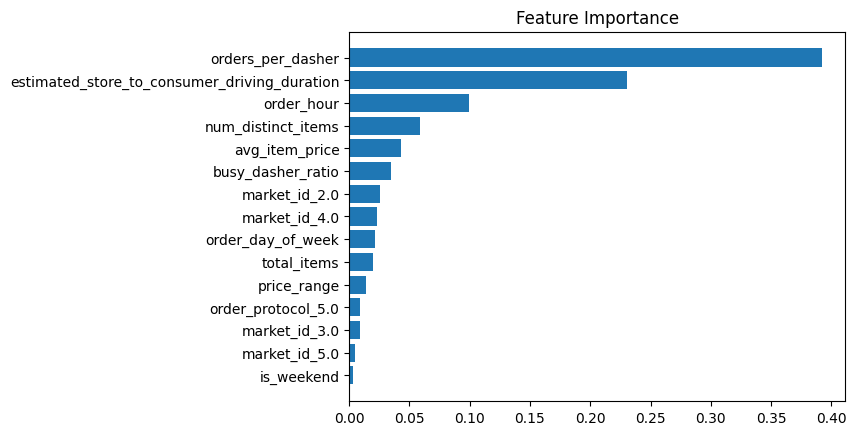

In [163]:
importances = rf_model.feature_importances_
features = X_train_rf.columns

indices = np.argsort(importances)[-15:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])
plt.title("Feature Importance")
plt.show()

The most important features for the model are :

1: orders_per_dasher

2: estimated_store_to_consumer_driving_duration

3: order_hour

4: number_of_distinct_items

5:busy_dasher_ratio

# Data Preparation for NN Model Training

In [115]:
df_model= df_new.copy()

In [116]:
df_model= df_model.drop(["created_at", "actual_delivery_time", "Time_taken_delivery","min_item_price","max_item_price","total_busy_dashers","total_onshift_dashers","subtotal","total_outstanding_orders"], axis=1)

In [117]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   store_primary_category                        175777 non-null  int64  
 2   order_protocol                                175777 non-null  float64
 3   total_items                                   175777 non-null  int64  
 4   num_distinct_items                            175777 non-null  int64  
 5   estimated_store_to_consumer_driving_duration  175777 non-null  float64
 6   order_hour                                    175777 non-null  int32  
 7   order_day_of_week                             175777 non-null  int32  
 8   is_weekend                                    175777 non-null  int64  
 9   delivery_in_minutes                           17

**Separate Categorical and Numeric Columns**

In [120]:
cat_cols = ["market_id", "store_primary_category", "order_protocol"]

In [121]:
num_cols = [
    "total_items",
    "num_distinct_items",
    "avg_item_price",
    "price_range",
    "orders_per_dasher",
    "busy_dasher_ratio",
    "estimated_store_to_consumer_driving_duration",
    "order_hour",
    "order_day_of_week",
    "is_weekend"
]

In [122]:
target = "delivery_in_minutes"

In [123]:
X_cat = df_model[cat_cols]
X_num = df_model[num_cols]
y = df_model[target]

## Train Test Split

In [124]:
X_cat_train, X_cat_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_cat, X_num, y, test_size=0.2, random_state=42)


**Scale Only numerical features**

In [125]:
scaler = StandardScaler()

X_num_train = scaler.fit_transform(X_num_train)
X_num_test = scaler.transform(X_num_test)

In [135]:
X_market_train = X_cat_train["market_id"].values
X_market_test = X_cat_test["market_id"].values

X_store_train = X_cat_train["store_primary_category"].values
X_store_test = X_cat_test["store_primary_category"].values

X_protocol_train = X_cat_train["order_protocol"].values
X_protocol_test = X_cat_test["order_protocol"].values

## Build the Embedding Model

### Inputs

In [126]:
market_input = Input(shape=(1,))
store_input = Input(shape=(1,))
protocol_input = Input(shape=(1,))
numeric_input = Input(shape=(X_num_train.shape[1],))

To calculate the embedding dimension we will use this formula : min(50, category/2)

### Embedding Layers

In [127]:
market_emb = Embedding(input_dim=df_model["market_id"].nunique(), output_dim=3)(market_input)
market_emb = Flatten()(market_emb)

store_emb = Embedding(input_dim=df_model["store_primary_category"].nunique(), output_dim=8)(store_input)
store_emb = Flatten()(store_emb)

protocol_emb = Embedding(input_dim=df_model["order_protocol"].nunique(), output_dim=2)(protocol_input)
protocol_emb = Flatten()(protocol_emb)

### Combine Inputs

In [128]:
x = Concatenate()([
    market_emb,
    store_emb,
    protocol_emb,
    numeric_input
])

# Model Training NN

## Training a Baseline NN Model

In [129]:
x = BatchNormalization()(x)

x = Dense(128, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(64, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(32, activation="relu")(x)

output = Dense(1)(x)

In [130]:
model = Model(
    inputs=[market_input, store_input, protocol_input, numeric_input],
    outputs=output
)

In [131]:
optimizer = Adam(learning_rate=0.0005)

In [132]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [133]:
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

In [136]:
model.compile(optimizer= optimizer ,loss = "mse", metrics = ["mae"])

In [137]:
history= model.fit([X_market_train, X_store_train, X_protocol_train, X_num_train],y_train, validation_split= 0.2, epochs=50, batch_size= 128, callbacks =[early_stop,lr_scheduler])

Epoch 1/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 614.0791 - mae: 16.4676 - val_loss: 16.0809 - val_mae: 3.0082 - learning_rate: 5.0000e-04
Epoch 2/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 17.2655 - mae: 2.9064 - val_loss: 12.6199 - val_mae: 2.6438 - learning_rate: 5.0000e-04
Epoch 3/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 13.3574 - mae: 2.6087 - val_loss: 11.3873 - val_mae: 2.5099 - learning_rate: 5.0000e-04
Epoch 4/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 11.1438 - mae: 2.4624 - val_loss: 10.3023 - val_mae: 2.3745 - learning_rate: 5.0000e-04
Epoch 5/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 10.0243 - mae: 2.3317 - val_loss: 9.7129 - val_mae: 2.3263 - learning_rate: 5.0000e-04
Epoch 6/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.8873 - mae: 2.2034 - val_loss: 8.3454 - val_mae: 2.1360 - learning_rate: 5.0000e-04
Epoch 7/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.1164 - mae: 2.1017 - val_loss: 8.1200 - val_mae: 2.

## Evaluate the model

In [138]:
model.evaluate(
    [X_market_test, X_store_test, X_protocol_test, X_num_test],
    y_test
)

1099/1099 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.3412 - mae: 1.6676


[5.259232521057129, 1.652323603630066]

## Plot Loss vs Epoch

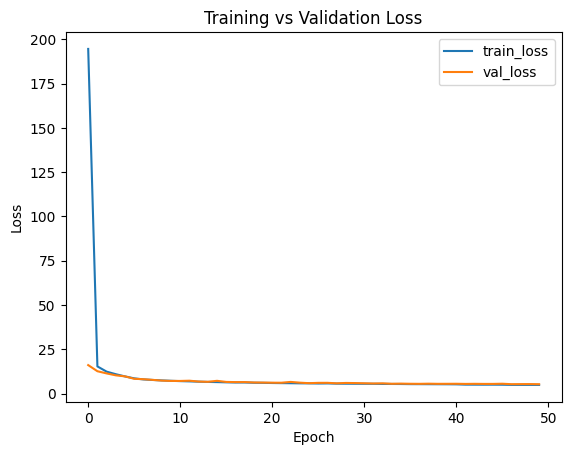

In [139]:
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.show()

## Prediction

In [141]:
y_pred = model.predict(
    [X_market_test, X_store_test, X_protocol_test, X_num_test]
)

1099/1099 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [143]:
y_pred = y_pred.flatten()

## Compute Error Metric

In [145]:
mae_nn = mean_absolute_error(y_test, y_pred)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred))
r2_nn = r2_score(y_test, y_pred)

In [146]:
print(f"MAE  : {mae_nn:.2f}")
print(f"RMSE : {rmse_nn:.2f}")
print(f"R2   : {r2_nn:.3f}")

MAE  : 1.65
RMSE : 2.29
R2   : 0.937


R² tells how much variance the model explains.In our case R squared is > 90% which explain model can explains most of the variance in the data.

RMSE is : 2.29 minutes

mae is 1.65 minutes.On average the model misses delivery time by ~1.65 minutes

# Compare Random Forest vs Neural Network

In [165]:
results = pd.DataFrame({
    "Model": ["Neural Network", "Random Forest"],
    "MAE": [mae, mae_rf],
    "RMSE": [rmse, rmse_rf],
    "R2": [r2, r2_rf]
})

print(results)

            Model       MAE      RMSE        R2
0  Neural Network  1.652323  2.293302  0.936785
1   Random Forest  2.014172  2.725116  0.910738


Here we can see that NN performs better than random Forest model which is evident from the fact that NN works well on large dataset. Usually for tabular data people prefer classical ML models but her we can see NN works very well.

# Hyperparameter Tuning (Random Search) BY Keras Tuner

In [147]:
import keras_tuner as kt

## Define the Hyperparameter Model Function

In [148]:
def build_model(hp):

    # Inputs
    market_input = Input(shape=(1,))
    store_input = Input(shape=(1,))
    protocol_input = Input(shape=(1,))
    numeric_input = Input(shape=(X_num_train.shape[1],))

    # Embeddings
    market_emb = Embedding(
        input_dim=df_model["market_id"].nunique(),
        output_dim=3
    )(market_input)

    market_emb = Flatten()(market_emb)

    store_emb = Embedding(
        input_dim=df_model["store_primary_category"].nunique(),
        output_dim=8
    )(store_input)

    store_emb = Flatten()(store_emb)

    protocol_emb = Embedding(
        input_dim=df_model["order_protocol"].nunique(),
        output_dim=2
    )(protocol_input)

    protocol_emb = Flatten()(protocol_emb)

    # Concatenate features
    x = Concatenate()([
        market_emb,
        store_emb,
        protocol_emb,
        numeric_input
    ])

    # Optional BatchNorm
    if hp.Boolean("batch_norm"):
        x = BatchNormalization()(x)

    # Tune number of hidden layers
    for i in range(hp.Int("num_layers", 1, 4)):

        units = hp.Int(
            f"units_{i}",
            min_value=32,
            max_value=256,
            step=32
        )

        activation = hp.Choice(
            "activation",
            ["relu", "elu", "tanh"]
        )

        x = Dense(units, activation=activation)(x)

        if hp.Boolean("batch_norm"):
            x = BatchNormalization()(x)

        if hp.Boolean("dropout"):
            x = Dropout(
                hp.Float(
                    "dropout_rate",
                    min_value=0.1,
                    max_value=0.5,
                    step=0.1
                )
            )(x)

    output = Dense(1)(x)

    model = Model(
        inputs=[market_input, store_input, protocol_input, numeric_input],
        outputs=output
    )

    # Tune learning rate
    lr = hp.Choice(
        "learning_rate",
        [1e-2, 1e-3, 5e-4, 1e-4]
    )

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )

    return model

## Create the Hyperparameter Tuner

In [151]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=5,
    executions_per_trial=1,
    directory="tuner_results",
    project_name="delivery_time_model"
)

Reloading Tuner from tuner_results/delivery_time_model/tuner0.json


max_trials = 20 different models tested

## Run Hyperparameter Search

In [166]:
tuner.search(
    [X_market_train, X_store_train, X_protocol_train, X_num_train],
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=128
)

Trial 6 Complete [00h 08m 26s]
val_loss: 7.009742259979248

Best val_loss So Far: 4.861782073974609
Total elapsed time: 00h 21m 49s


## Retrieve Best Model

In [167]:
best_model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 40 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [168]:
best_hp = tuner.get_best_hyperparameters(1)[0]

print(best_hp.values)

{'batch_norm': True, 'num_layers': 3, 'units_0': 192, 'activation': 'elu', 'dropout': False, 'learning_rate': 0.01, 'dropout_rate': 0.30000000000000004, 'units_1': 224, 'units_2': 64, 'units_3': 256}


## Plot Loss Vs Epoch

In [170]:
history = best_model.fit(
    [X_market_train, X_store_train, X_protocol_train, X_num_train],
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=128
)

Epoch 1/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.6662 - mae: 1.6242 - val_loss: 5.3459 - val_mae: 1.6309
Epoch 2/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.7546 - mae: 1.6400 - val_loss: 4.8760 - val_mae: 1.5272
Epoch 3/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.8984 - mae: 1.6636 - val_loss: 4.8350 - val_mae: 1.4995
Epoch 4/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 4.7754 - mae: 1.6465 - val_loss: 6.7088 - val_mae: 1.8918
Epoch 5/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 4.7887 - mae: 1.6509 - val_loss: 4.9075 - val_mae: 1.5303
Epoch 6/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 4.6484 - mae: 1.6185 - val_loss: 5.8984 - val_mae: 1.7096
Epoch 7/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 4.5905 - mae: 1.6119 - val_loss: 4.8212 - val_mae: 1.5030
Epoch 8/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 4.6958 - mae: 1.6351 - val_loss: 5.0275 - val_mae: 1.5996
Epoch 9/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - lo

In [171]:
best_model.evaluate(
    [X_market_test, X_store_test, X_protocol_test, X_num_test],
    y_test
)

1099/1099 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 5.5962 - mae: 1.6992


[5.5870041847229, 1.69205641746521]

## Predictions

In [172]:
y_pred = best_model.predict(
    [X_market_test, X_store_test, X_protocol_test, X_num_test]
)

y_pred = y_pred.flatten()

1099/1099 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


## Compute the Error Metric

In [173]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.6920549893680321
RMSE: 2.363684757964897
R2: 0.9328452563063188


# Leading Questions :

**List 3 functions the pandas datetime provides with one line explanation.**

**Ans:**

.dt.hour :Extracts the hour (0–23) from a datetime column.

.dt.weekday : Returns the day of the week as an integer (0 = Monday, 6 = Sunday).

.dt.date : Extracts only the date part (YYYY-MM-DD) from a datetime value, removing the time component.


Short note on datetime, timedelta, time span (period)

**Why do we need to check for outliers in our data?**

Ans: Prevent model distortion, Improve model accuracy and stability, Detect data quality issues, Understand rare but important events



**Name 3 outlier removal methods?**

Ans:

1️⃣ IQR Method (Interquartile Range)
Detects outliers using the spread of the middle 50% of the data.
Values outside Q1 − 1.5 × IQR or Q3 + 1.5 × IQR are considered outliers.

2️⃣ Z-Score Method
Measures how many standard deviations a value is from the mean.
Values with |z-score| > 3 are usually treated as outliers.

3️⃣ Percentile Clipping (Winsorization)
Caps extreme values at certain percentiles (e.g., 1st and 99th percentile) instead of removing rows.
Commonly used in ML to keep dataset size stable.

**What classical machine learning methods can we use for this problem?**

Random forest, Gradient Boosting

**Why is scaling required for neural networks?**

**Ans**

Ensures Stable Gradient Descent

Prevents Certain Features from Dominating

Improves Convergence Speed

**Briefly explain your choice of optimizer.**

**Ans:**

I chose the Adam optimizer because it combines the advantages of momentum and adaptive learning rates, making training faster and more stable.

**Which activation function did you use and why?**

**Ans** I used the ReLU (Rectified Linear Unit) activation function because it helps neural networks train faster and reduces common issues like the vanishing gradient problem.

ReLU outputs the input directly if it is positive and returns 0 for negative values. This simple behavior allows gradients to propagate efficiently through the network, enabling faster learning and better performance for deep models.



**Why does a neural network perform well on a large dataset?**

**Ans**

High Model Capacity : Neural networks contain many weights and layers

Reduced Overfitting

Better Representation Learning

